#Image Classification HRnet / Vision Transformers / Mobilenet



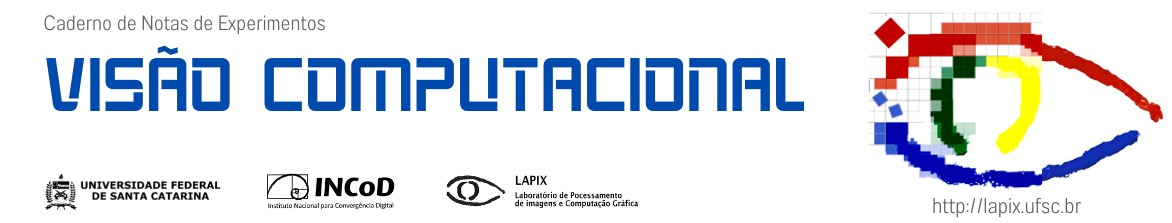

# Autores:


* Aldo Von Wangenheim (aldo.vw@ufsc.br)
* Thiago Zimmermann Loureiro Chaves (thiago.zlc@grad.ufsc.br)
* Rodrigo de Paula e Silva Ribeiro (ribeiro.rodrigo@posgrad.ufsc.br)





<a href="https://colab.research.google.com/github/awangenh/vision/blob/master/jupyter/12.4.Classifica%C3%A7%C3%A3o%20de%20Imagens%20HRnet.ipynb"><img align="left"  src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab" title="Open and Execute in Google Colaboratory"></a>&nbsp; &nbsp;<a href=""><img align="left" src="http://www.lapix.ufsc.br/wp-content/uploads/2019/04/License-CC-BY-ND-4.0-orange.png" alt="Creative Commons 4.0 License" title="Creative Commons 4.0 License"></a>&nbsp; &nbsp; <a href=""><img align="left" src="http://www.lapix.ufsc.br/wp-content/uploads/2019/04/Jupyter-Notebook-v.1.0-blue.png" alt="Jupyter Version" title="Jupyter Version"></a>&nbsp; &nbsp;<a href=""><img align="left"  src="https://img.shields.io/badge/python-3.10-greeng" alt="Python Version" title="Python Version"></a>

# Para utilizar a placa de vídeo no Google Colab...

1) clique no ▾ do lado de "Conectar"

2) Ver recursos

3) Alterar o tipo de ambiente de execução

4) Acelerador de hardware: GPU

5) Execute a célula abaixo. Ela deve retornar as informações da placa de vídeo.

SE ESTIVER UTILIZANDO NO LAPIX DEFINIR A GPU A SER UTILIZADA NO CÓDIGO ABAIXO

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
!nvcc --version

try:
    import google.colab
    _ON_COLAB = True
except:
    _ON_COLAB = False

print('Running on Google Colab = ', _ON_COLAB)
import os
import torch
from IPython import get_ipython
import os
# Definir o caminho base
if _ON_COLAB:
    BASE_PATH = "/content"
    import locale
    locale.getpreferredencoding = lambda: "UTF-8"
else:
    BASE_PATH = "/lapix" # trocar para o base path do seu computador se estiver rodando localmente, deixar /lapix se estiver rodando nos conteiners lapix
    VISIBLE_GPUS = [6] # Selecionar a GPU PARA RODAR! VER QUAL ESTA LIVRE

    if torch.cuda.device_count() != 8:
        print("GPU SETADA - PULANDO ETAPA")
    else:
        os.environ["CUDA_VISIBLE_DEVICES"] = str(VISIBLE_GPUS).replace("]", "").replace("[","").replace(" ", "")
        os.environ["NVIDIA_VISIBLE_DEVICES"] = str(VISIBLE_GPUS).replace("]", "").replace("[","").replace(" ", "")
        print("CUDA GPUS NUMBER: ", torch.cuda.device_count())

os.chdir(BASE_PATH) # garantir que está executando no caminho base definido

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Mar_28_02:18:24_PDT_2024
Cuda compilation tools, release 12.4, V12.4.131
Build cuda_12.4.r12.4/compiler.34097967_0
Running on Google Colab =  False
GPU SETADA - PULANDO ETAPA


/root/anaconda3/envs/lapixdl/lib/python3.11/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


#Instalando as Bibliotecas Necessárias

---

In [3]:
!pip install fastai timm

DEPRECATION: Loading egg at /root/anaconda3/envs/lapixdl/lib/python3.11/site-packages/paddleseg-0.0.0.dev0-py3.11.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
from fastai.vision.all import *
import timm

Download Dataset

---



## OPÇÃO 1: DATASET CUSTOM

Se você deseja carregar um **conjunto de dados cutomizado** seu, utilize esta célula aqui, adaptando os parâmetros para o caminho para o qual você realizou o download das suas imagens.

Observe que esta célula parte da premissa de que você **já baixou** seus dados para alguma pasta da máquina virtual do Colab, seja através da conexão com o Google Drive na célula mais acima, se através de upload manual do seu computador ou de download manual para o Colab.

In [ ]:
from google.colab import drive
import os
drive.mount(os.path.join(BASE_PATH, "gdrive"))
DRIVE_BASE_PATH = os.path.join(BASE_PATH, "gdrive")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [3]:
path = Path("/home/jovyan/arquivos/DATASET/") #Pasta base do dataset
train_path = path/'train' # subpasta com o conjunto de treinamento
valid_path = path/'validation' # subpasta com o conjunto de validação
test_path = path/'test' # subpasta com o conjunto de teste
#size = 512 # resize das imagens deste dataset para a rede
size = 224 # para VIT e mobilevnet
batch_size = 16 # batch size deste dataset

# Definindo Datablock


In [40]:
# 1. Listar classes selecionadas (500 primeiras do treino)
train_classes = sorted(os.listdir(path/'train'))[:500]
selected_classes = set(train_classes)

# 2. Função get_items personalizada com filtro
def get_items(path):
    items = []
    # Coletar imagens apenas das classes selecionadas em train/validation
    for folder in ['train', 'validation']:
        for cls in selected_classes:
            cls_path = path/folder/cls
            if cls_path.exists():
                items += get_image_files(cls_path)
    return items

# 3. Construir DataBlock
dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_items,
    splitter=GrandparentSplitter(train_name='train', valid_name='validation'),
    get_y=parent_label,
    item_tfms=Resize(size),
    batch_tfms=[*aug_transforms(size=size), Normalize.from_stats(*imagenet_stats)]
)

# 4. Criar DataLoaders
dls = dblock.dataloaders(path, bs=batch_size, num_workers=0)

# 5. DataLoader de teste
def get_test_items():
    test_items = []
    for cls in selected_classes:
        cls_path = path/'test'/cls
        if cls_path.exists():
            test_items += get_image_files(cls_path)
    return test_items

dblock2 = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_items,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=Resize(size),
    batch_tfms=[*aug_transforms(size=size), Normalize.from_stats(*imagenet_stats)]
)
dt = dblock2.dataloaders(path, bs=batch_size, num_workers=0)

test_dl = dt.test_dl(get_test_items())

In [5]:
print(f"Train samples: {len(dls.train_ds)}")
print(f"Valid samples: {len(dls.valid_ds)}")

Train samples: 6212
Valid samples: 2124


# Mostrando um Batch

---



/root/anaconda3/envs/lapixdl/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Glyph 20162 (\N{CJK UNIFIED IDEOGRAPH-4EC2}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/root/anaconda3/envs/lapixdl/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Glyph 20447 (\N{CJK UNIFIED IDEOGRAPH-4FDF}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/root/anaconda3/envs/lapixdl/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Glyph 20016 (\N{CJK UNIFIED IDEOGRAPH-4E30}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/root/anaconda3/envs/lapixdl/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Glyph 20280 (\N{CJK UNIFIED IDEOGRAPH-4F38}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/root/anaconda3/envs/lapixdl/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Glyph 20307 (\N{CJK UNIFIED IDEOGRAPH-4F53}) missing from font(s) DejaVu Sans.
  func(*args, **kwa

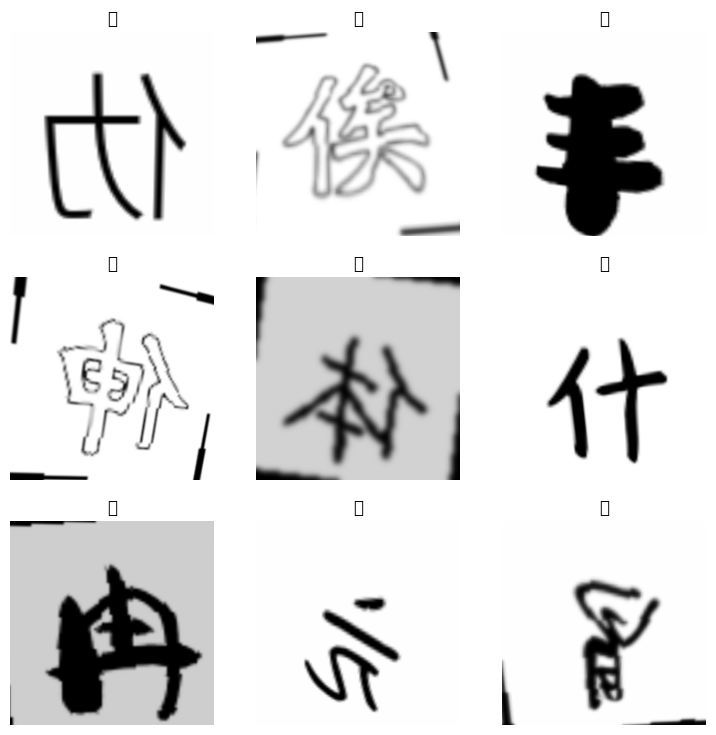

In [6]:
dls.show_batch()

## HRNet


---


Apesar de tecnicamente as Redes Neurais de Alta Resolução (*High Resolution Neural Network* - **HRNet**) não serem um modelo de transformador visual, a sua variação mais recente, a **HRNet+OCR** (*HRNet plus Object Context Recognition*) possui um mecanismo de atenção primitivo a título de pós-processamento que faz com que vários autores as classifiquem na categoria de transformadores visuais (esse é o caso do pacote PaddleSeg, que a incorpora, chamando-a de OCRNet). HRNet é uma rede neural de arquitetura homogênea, linear e sequencial, no melhor estilo das redes neurais VGG, lá do começo da era do aprendizado profundo, mas que possui como diferencial o fato de dividir o fluxo de processamento em quatro fluxos paralelos de resoluções diferentes 1/1, 1/2, 1/4 e 1/8 de resolução. A linearidade da sequência de processamento é quebrada apenas por um conjunto de conexões verticais integrando os quatro fluxos em intervalos regulares.

A rede HRNet pode ser terminada em três tipos de cabeças diferentes, dependendo se a função é classificação de imagens, detecção de objetos ou segmentação semântica. A arquitetura para essas três categorias de aplicação se diferencia apenas pela cabeça ao final. É um modelo de rede neural que utiliza muita memória e normalmente são indicadas placas gráficas com 24 GB ou mais para treinar uma instância de HRNet, embora para conjunto de dados pequenos seja possível treiná-la em placas de 16 GB. De um ponto de vista de estética matemática, essa homogeneidade do modelo e estrutura simples e lógica que a HRNet utiliza a torna um modelo bonito e fácil de compreender, tornando o modelo adequado para fins didáticos também.

![banner cnns ppgcc ufsc](http://lapix.ufsc.br/wp-content/uploads/2022/12/hrnet-ocr.jpg)


A figura acima ilustra as duas possíveis arquiteturas de HRNet: arquitetura clássica de 2019 (a) termina com um bloco que possui conjunto de operações de convolução 1x1 na posição  (c) que integram os quatro fluxos de processamento multi-resolução e alimentam uma cabeça de classificação de imagens, detecção de objetos ou segmentação semântica. Já a versão mais moderna, HRNet+OCR, de 2021, possui na posição (c) um bloco Object Context Recognition, representado em (b). De forma muito simplificada esse bloco toma as saídas multi-resolução, representadas como a caixinha "backbone", que são utilizadas para gerar, por um lado, representações  de segmentos "normais", cujas vizinhanças são mapeadas no fluxo superior, como também para formar "soft regions" multi-escala em que os pixels de cada região são colocados em contexto uns em relação aos outros, criando-se uma representação da relação entre cada pixel e cada região. Ao final, essa representação é utilizada para corrigir e melhorar a segmentação semântica original. Em um de seus artigos os autores também descrevem a possibilidade de se usar simplesmente uma ResNet101 como backbone, incorporando-se o módulo OCR à sua saída.

### Referências de HRNets

* Deep High-Resolution Representation Learning for Visual Recognition. https://arxiv.org/pdf/1908.07919.pdf
* High-Resolution Representations for Object Detection. https://arxiv.org/pdf/1904.04514.pdf
* Object-Contextual Representations for Semantic Segmentation. https://arxiv.org/pdf/1909.11065.pdf
* https://github.com/HRNet/HRNet-Image-Classification
* https://github.com/HRNet/HRNet-Object-Detection
* https://github.com/HRNet/HRNet-Semantic-Segmentation






# Selecionamos a Rede Neural


*   Hrnet18, Hrnet32, Hrnet48
*   VIT_base_patch, VIT_small_patch
*   MobiletnetV3

---



Para mais modelos:
https://github.com/huggingface/pytorch-image-models/tree/main/timm/models

In [7]:
def hrnet18(pretrained=True):
    model = timm.create_model("hrnet_w18_small_v2", pretrained=pretrained)
    return model

def hrnet32(pretrained=True):
    model = timm.create_model("hrnet_w32", pretrained=pretrained)
    return model

def hrnet48(pretrained=True):
    model = timm.create_model("hrnet_w48", pretrained=pretrained)
    return model

def vit_base_patch16_224(num_classes=3, pretrained=True):
    model = timm.create_model("vit_base_patch16_224", pretrained=pretrained, num_classes=num_classes)
    return model

def vit_small_patch16_224(num_classes=3, pretrained=True):
    model = timm.create_model("vit_small_patch16_224", pretrained=pretrained, num_classes=num_classes)
    return model

def mobilenetv3(pretrained=True):
    model = timm.create_model("mobilenetv3_large_100.ra_in1k", pretrained=pretrained)
    return model

#model = hrnet18(pretrained=True)
model = mobilenetv3(pretrained=True)      ##NOTE: vou usar mobilenetv3 e VIT
#model = vit_small_patch16_224(pretrained=True, num_classes = 500)  # diminuir 

# Definindo o Learner

---



In [8]:
# Create model with pre-trained weights
learn = Learner(dls, model, loss_func=CrossEntropyLossFlat(), metrics=accuracy,path="/home/jovyan/arquivos/DATASET/models/vit1000")

# Treinando o Modelo

---



### Treinamos utilizando a política de adaptação simultânea de taxa de aprendizado e momento linear da rede para superconvergência 1cycle

Abaixo um explicação retirada de nosso tutorial "How to resume an interrupted training session in fastai" disponível em: https://towardsdatascience.com/how-to-resume-an-interrupted-training-session-in-fastai-77c4f36cd3a1

O método fit_one_cycle() empregado pelo fast.ai funciona com taxas e momentos de aprendizado variados e adaptativos, seguindo uma curva em que a taxa é aumentada e depois diminuída, enquanto o momento é tratado de forma oposta, conforme mostrado na figura abaixo.

![imagem](https://miro.medium.com/max/720/1*38YBWIKFwXN0YlNOVo_LOA.jpeg)

Se você interromper um treino na epoch #10 de, digamos, 20 epochs e depois recomeçar por mais 9 epochs, você não terá o mesmo resultado de treinar ininterruptamente por 20 epochs, porque um novo treino do zero, mesmo que você carregue os pesos da última época, empregarão uma nova taxa de aprendizado e política de impulso e passarão pelo ciclo novamente.

O que você quer é começar de onde você foi interrompido no ciclo.

![imagem](https://miro.medium.com/max/720/0*AzuB9-kayY2Abfp3.png)

### O que é fit1cycle?

Fit1cycle é uma política de superconvergência desenvolvida por Leslie N. Smith. Está disponível como a política de treinamento preferida no fast.ai. Veja abaixo os detalhes:

* https://docs.fast.ai/callbacks.one_cycle.html
* A disciplined approach to neural network hyper-parameters: Part 1 — learning rate, batch size, momentum, and weight decay — https://arxiv.org/abs/1803.09820
* Super-Convergence: Very Fast Training of Residual Networks Using Large Learning Rates — https://arxiv.org/abs/1708.07120

Se você quiser ver mais artigos, siga este link: Papers de Leslie N. Smith. Não entraremos em detalhes nesta postagem. Existem várias postagens no Medium apresentando e discutindo a política de treinamento fit1cycle de uma maneira fácil de ler:

* Training Neural Networks upto 10x Faster by Karanbir Chahal;
* SuperConvergence with inbuilt regularization by Yogesh Gurjar;
* Super-Convergence: Very Fast Training of Neural Networks Using Large Learning Rates by Aditya Gupta;
* Fast.ai Part1 v2/v3 Notes — Learning Rates — from SGDR to 1cycle and Super-Convergence by Roger Mao;
* Reproducing Leslie N. Smith’s papers using fastai by Kushajveer Singh.

Esta última postagem de Kushajveer Singh tem um notebook Jupyter muito ilustrativo que vale a pena olhar. Há também um artigo muito interessante de Nachiket Tanksale chamado Finding Good Learning Rate e The One Cycle Policy, onde as taxas de aprendizado cíclico e o momento são discutidos.

Leia o nosso tutorial para saber mais sobre treino em etapas e 1cycle.

In [9]:
learn.fit_one_cycle(20)

epoch,train_loss,valid_loss,accuracy,time
0,6.065373,5.912884,0.010829,20:46
1,3.301289,2.021985,0.531073,40:16
2,1.430449,0.769858,0.782015,30:59
3,0.855073,0.564935,0.839925,29:44
4,0.676388,0.433856,0.890301,36:26
5,0.461856,0.282527,0.917608,36:10
6,0.352082,0.239849,0.938795,23:16
7,0.220949,0.120058,0.970339,21:25
8,0.186922,0.096969,0.977401,25:55
9,0.130849,0.098582,0.973635,22:52


IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



KeyboardInterrupt: 

In [ ]:
# Evaluate model on validation set
interp = ClassificationInterpretation.from_learner(learn)

# Display best 5 and worst 5 results
interp.plot_top_losses(5, figsize=(20,20))
interp.plot_top_losses(5, largest=False, figsize=(20,20))

# Display heatmap of accuracy for each class
interp.plot_confusion_matrix(figsize=(12, 12), cmap='Blues')

# Salvando o Modelo

---



In [10]:
learn.save("/home/jovyan/arquivos/VIT100-hanzi")

Path('/home/jovyan/arquivos/VIT100-hanzi.pth')

# Testando o modelo

---

In [13]:
bs = 1
path_test = path / "test" 
data_test = ImageDataLoaders.from_folder(path = path,train='test',valid='test',test = path_test, bs=bs,
                                    batch_tfms=Normalize.from_stats(*imagenet_stats),)

In [41]:
ds_test = dt.valid_ds

In [42]:
from fastai.vision.all import *
from lapixdl.evaluation.evaluate import evaluate_classification
from lapixdl.evaluation.model import Classification
from IPython.display import Image

def gt_classifications(ds):
    for (img, cls) in ds:
        yield Classification(int(cls))


def pred_classifications(ds):
    for (img, cls) in ds:
        (cls_name, pred_cls, scores) = learn.predict(img)
        yield Classification(int(pred_cls), scores[int(pred_cls)])


def top5(img):
  pred_class, pred_idxs, outputs = learn.predict(img)
  top_5_conf, i = outputs.topk(5)
  itr = 0
  classes = data.classes
  for x in i:
    print("Class: %s, Probability: %.4f %%"%(classes[x.item()], top_5_conf[itr].item()*100))
    itr=itr+1
  print()

def get_prediction(img,correct):
  pred_class, pred_idxs, outputs = learn.predict(img)
  classes = data.classes
  out = list(outputs)
  index = classes.index(correct)
  prediction = out[index]
  print("%.10f %%"%(prediction.item()*100))
  print()



evaluation_test = evaluate_classification(
    gt_classifications(ds_test), pred_classifications(ds_test), ds_test.vocab
)

0 samples [00:00, ? samples/s]

/root/anaconda3/envs/lapixdl/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 13383 (\N{CJK UNIFIED IDEOGRAPH-3447}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/root/anaconda3/envs/lapixdl/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 13386 (\N{CJK UNIFIED IDEOGRAPH-344A}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/root/anaconda3/envs/lapixdl/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 13678 (\N{CJK UNIFIED IDEOGRAPH-356E}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/root/anaconda3/envs/lapixdl/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 13838 (\N{CJK UNIFIED IDEOGRAPH-360E}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/root/anaconda3/envs/lapixdl/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 13901 (\N{CJK UNIFIED IDEOGRAPH-364D}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/root/anaconda3/envs/lapixdl/lib/python3.11/s

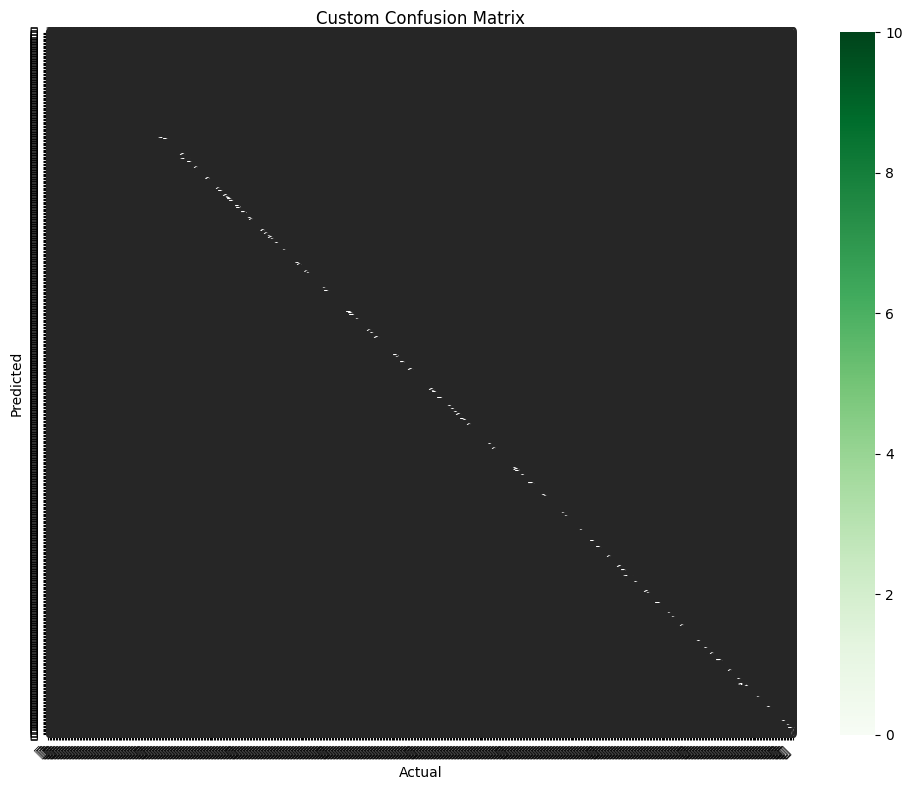

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = evaluation_test.confusion_matrix
labels = ds_test.vocab

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Predicted')
plt.title('Custom Confusion Matrix')
plt.tight_layout()
plt.show()

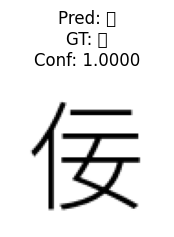

In [44]:
img, label = ds_test[4]
pred_class, pred_idx, outputs = learn.predict(img)


img.show()
plt.title(f"Pred: {pred_class}\nGT: {ds_test.vocab[label]}\nConf: {outputs[pred_idx]:.4f}")
plt.show()


In [45]:
print("Métricas Globais:")
print(f"Accuracy:          {evaluation_test.accuracy:.4f}")
print(f"F1 Score:          {evaluation_test.avg_f_score:.4f}")
print(f"Precision:         {evaluation_test.avg_precision:.4f}")
print(f"Recall:            {evaluation_test.avg_recall:.4f}")
print(f"Specificity:       {evaluation_test.avg_specificity:.4f}")
print(f"FPR:               {evaluation_test.avg_false_positive_rate:.4f}")

Métricas Globais:
Accuracy:          0.9880
F1 Score:          0.9876
Precision:         0.9895
Recall:            0.9879
Specificity:       1.0000
FPR:               0.0000


In [46]:
print("Métricas por classe:")
by_class = evaluation_test.by_class

for c, metric in zip(ds_test.vocab, by_class):
    print(f"\nClasse: {c}")
    print(f"  F1 Score:        {metric.f_score:.4f}")
    print(f"  Precision:       {metric.precision:.4f}")
    print(f"  Recall:          {metric.recall:.4f}")
    print(f"  Specificity:     {metric.specificity:.4f}")
    print(f"  FPR:             {metric.false_positive_rate:.4f}")

Métricas por classe:

Classe: 㑇
  F1 Score:        1.0000
  Precision:       1.0000
  Recall:          1.0000
  Specificity:     1.0000
  FPR:             0.0000

Classe: 㑊
  F1 Score:        1.0000
  Precision:       1.0000
  Recall:          nan
  Specificity:     1.0000
  FPR:             0.0000

Classe: 㕮
  F1 Score:        1.0000
  Precision:       1.0000
  Recall:          nan
  Specificity:     1.0000
  FPR:             0.0000

Classe: 㘎
  F1 Score:        1.0000
  Precision:       1.0000
  Recall:          nan
  Specificity:     1.0000
  FPR:             0.0000

Classe: 㙍
  F1 Score:        1.0000
  Precision:       1.0000
  Recall:          nan
  Specificity:     1.0000
  FPR:             0.0000

Classe: 㙘
  F1 Score:        1.0000
  Precision:       1.0000
  Recall:          nan
  Specificity:     1.0000
  FPR:             0.0000

Classe: 㙦
  F1 Score:        1.0000
  Precision:       1.0000
  Recall:          nan
  Specificity:     1.0000
  FPR:             0.0000

Classe: 㛃

In [47]:
df = evaluation_test.to_dataframe()

In [48]:
df.to_csv('test_results.csv')